### ============================================================
### Load HC3 (Human ChatGPT Comparison Corpus) — Google Colab
### https://huggingface.co/datasets/Hello-SimpleAI/HC3  (config: "all")
### ============================================================

In [ ]:
!pip -q install -U datasets huggingface_hub

In [ ]:
import pandas as pd
print(pd.__version__)

2.2.3


In [ ]:
import pandas as pd

# HC3 is just jsonl files on the hub = one per domain (5 domains) + all.jsonl (JSONL store each row/line as 1 object)
# all 5 combined (finance, medicine, general Q&A, Reddit ELI5, and Wikipedia computer-science.)
# read it straight over the hf:// filesystem (huggingface_hub library), skip the datasets library and its script/config mess
hc3 = pd.read_json("hf://datasets/Hello-SimpleAI/HC3/all.jsonl", lines=True)

print(hc3.shape)                     # one row per question
print(hc3["source"].value_counts())  # questions per domain
hc3.head()

(24322, 5)
source
reddit_eli5    17112
finance         3933
medicine        1248
open_qa         1187
wiki_csai        842
Name: count, dtype: int64


,question,human_answers,chatgpt_answers,index,source
0,"Why is every book I hear about a "" NY Times # ...","[Basically there are many categories of "" Best...",[There are many different best seller lists th...,NaN,reddit_eli5
1,"If salt is so bad for cars , why do we use it ...",[salt is good for not dying in car crashes and...,[Salt is used on roads to help melt ice and sn...,NaN,reddit_eli5
2,Why do we still have SD TV channels when HD lo...,[The way it works is that old TV stations got ...,[There are a few reasons why we still have SD ...,NaN,reddit_eli5
3,Why has nobody assassinated Kim Jong - un He i...,[You ca n't just go around assassinating the l...,[It is generally not acceptable or ethical to ...,NaN,reddit_eli5
4,How was airplane technology able to advance so...,[Wanting to kill the shit out of Germans drive...,[After the Wright Brothers made the first powe...,NaN,reddit_eli5


In [ ]:
hc3.drop(columns="index")

,question,human_answers,chatgpt_answers,source
0,"Why is every book I hear about a "" NY Times # ...","[Basically there are many categories of "" Best...",[There are many different best seller lists th...,reddit_eli5
1,"If salt is so bad for cars , why do we use it ...",[salt is good for not dying in car crashes and...,[Salt is used on roads to help melt ice and sn...,reddit_eli5
2,Why do we still have SD TV channels when HD lo...,[The way it works is that old TV stations got ...,[There are a few reasons why we still have SD ...,reddit_eli5
3,Why has nobody assassinated Kim Jong - un He i...,[You ca n't just go around assassinating the l...,[It is generally not acceptable or ethical to ...,reddit_eli5
4,How was airplane technology able to advance so...,[Wanting to kill the shit out of Germans drive...,[After the Wright Brothers made the first powe...,reddit_eli5
...,...,...,...,...
24317,Is rise in pressure from 116/66 to 140/80 norm...,[Hello!Welcome and thank you for asking on HCM...,[It's not uncommon for blood pressure to fluct...,medicine
24318,What could cause a painless lump in the right ...,"[Hi, * As per my surgical experience, the issu...",[There are several possible causes of a painle...,medicine
24319,Can Acutret be given to a child for treatment ...,[Although it is difficult to comment whether A...,[It is not appropriate for me to recommend a s...,medicine
24320,Are BP of 119/65 and pulse of 35 causes for co...,[Welcome and thank you for asking on HCM! I ha...,[It is not uncommon for people with rheumatoid...,medicine


### HC3 dataset does not have any null values

In [ ]:
print(hc3["human_answers"][0])

['Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you \'re still an " oscar - winning " film . Same thing for best sellers . Also , IIRC the rankings change every week or something like that . Some you might not be best seller one week , but you may be the next week . I guess even if you do n\'t stay there for long , you still achieved the status . Hence , # 1 best seller .', "If you 're hearing about it , it 's because it was a very good or very well - publicized book ( or both ) , and almost every good or well - publicized book will be # 1 on the NY Times bestseller list for at least a little bit . Kindof like how almost every big or good movies are # 1 at the box office on their opening weekend .", "One reason is lots of catagories . However , how the NY Time

In [ ]:
print("Missing values:")
print(hc3[["question", "human_answers", "chatgpt_answers"]].isna().sum())

Missing values:
question           0
human_answers      0
chatgpt_answers    0
dtype: int64


In [ ]:
hc3["human_word_count"] = hc3["human_answers"].apply(lambda x: len(x[0].split()) if len(x) > 0 else 0)
hc3["chatgpt_word_count"] = hc3["chatgpt_answers"].apply(lambda x: len(x[0].split()) if len(x) > 0 else 0)

print("Human answers with <=1 word:", (hc3["human_word_count"] <= 1).sum())
print("ChatGPT answers with <=1 word:", (hc3["chatgpt_word_count"] <= 1).sum())

hc3[
    (hc3["human_word_count"] <= 1) |
    (hc3["chatgpt_word_count"] <= 1)
][
    ["question", "human_answers", "chatgpt_answers",
     "human_word_count", "chatgpt_word_count"]
]

Human answers with <=1 word: 1
ChatGPT answers with <=1 word: 458


,question,human_answers,chatgpt_answers,human_word_count,chatgpt_word_count
8172,How is soil formed ? Is there soil on moon?If ...,[Does n't soil consist of a number of differen...,[],32,0
8173,What is earwax and why do we have it ? I was j...,[What is it ? Not sure what the chemical compo...,[],70,0
8438,"Why is it that Jalapeño is spelt with a "" J "" ...",[Because Spanish orthography has rules that di...,[],40,0
8439,What is the difference between mexican soda an...,[Soda made in the U.S. has been made from high...,[],111,0
8681,How is soil formed ? Is there soil on moon?If ...,[Does n't soil consist of a number of differen...,[],32,0
...,...,...,...,...,...
11723,Why do roller skates have such a negative resp...,[> They were the shit in the 90 's so what hap...,[],82,0
19909,"As a Sole Proprietor, will “employer” Solo 401...",[This seems to depend on what kind of corporat...,[还有就是办卡的手机号码没用了可挂失不如果您的手机号码没有用了，您可以考虑挂失您的银行卡。挂...,321,1
23177,"Pressure in temple, whooshing sensation. Is it...",[Hello],[It is possible that the sensation you are exp...,1,127
23832,"Kidney infection, weird twinges in bladder and...","[hi, urinary infections need to be treated. If...",[],72,0


In [ ]:
hc3_clean = hc3[
    (hc3["human_answers"].apply(len) > 0) &
    (hc3["chatgpt_answers"].apply(len) > 0)
].copy()

print(hc3_clean.shape)
hc3_clean.head()

(23867, 7)


,question,human_answers,chatgpt_answers,index,source,human_word_count,chatgpt_word_count
0,"Why is every book I hear about a "" NY Times # ...","[Basically there are many categories of "" Best...",[There are many different best seller lists th...,NaN,reddit_eli5,134,207
1,"If salt is so bad for cars , why do we use it ...",[salt is good for not dying in car crashes and...,[Salt is used on roads to help melt ice and sn...,NaN,reddit_eli5,41,199
2,Why do we still have SD TV channels when HD lo...,[The way it works is that old TV stations got ...,[There are a few reasons why we still have SD ...,NaN,reddit_eli5,166,146
3,Why has nobody assassinated Kim Jong - un He i...,[You ca n't just go around assassinating the l...,[It is generally not acceptable or ethical to ...,NaN,reddit_eli5,122,145
4,How was airplane technology able to advance so...,[Wanting to kill the shit out of Germans drive...,[After the Wright Brothers made the first powe...,NaN,reddit_eli5,11,199


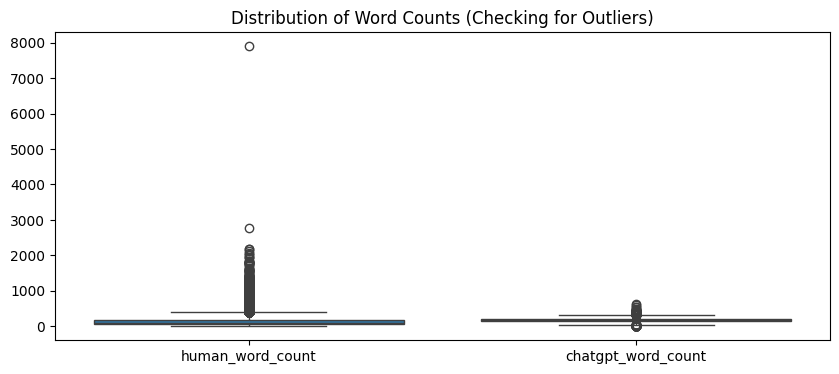

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(data=hc3_clean[["human_word_count", "chatgpt_word_count"]])
plt.title("Distribution of Word Counts (Checking for Outliers)")
plt.show()

New maximum human word count: 2182


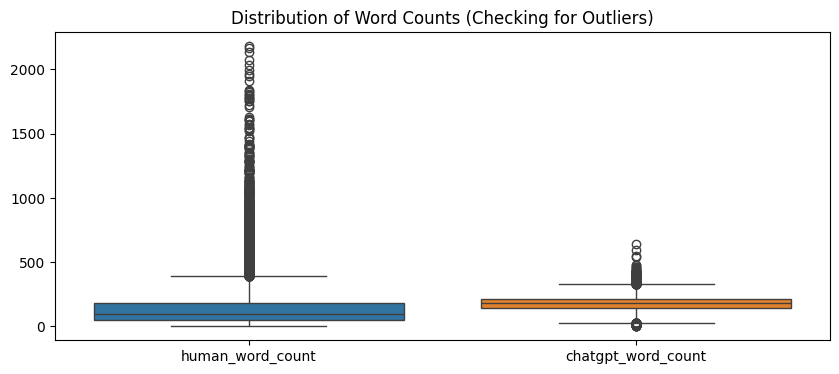

In [ ]:
hc3_clean = hc3_clean[hc3_clean["human_word_count"] <= 2600].copy()
print("New maximum human word count:", hc3_clean["human_word_count"].max())

# New visualization after dropping the 8000 word count outlier

plt.figure(figsize=(10, 4))
sns.boxplot(data=hc3_clean[["human_word_count", "chatgpt_word_count"]])
plt.title("Distribution of Word Counts (Checking for Outliers)")
plt.show()

In [ ]:
import re
import unicodedata

def normalize_text(text):
    if isinstance(text, list):
        return [normalize_text(x) for x in text]

    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text)  # replace weird spacing with one space
    text = text.strip()

    return text

hc3_clean["question"] = hc3_clean["question"].apply(normalize_text)
hc3_clean["human_answers_normalized"] = hc3_clean["human_answers"].apply(normalize_text)
hc3_clean["chatgpt_answers_normalized"] = hc3_clean["chatgpt_answers"].apply(normalize_text)

Drop duplicates

In [ ]:
hc3_split = hc3_clean.drop_duplicates(subset=["question"]).copy()

**Train/ Test/ Validation Split**

breakdown summary:
- 80% train
- 10% test
- 10% validation

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#first split: 80% train and 20% other
train_questions, temp_questions = train_test_split(hc3_split, test_size=0.20, random_state=42, stratify=hc3_split["source"])

In [ ]:
#split that remaining 20% evenly: 10% validation and 10% test
val_questions, test_questions = train_test_split(temp_questions, test_size=0.50, random_state=42, stratify=temp_questions["source"])

In [ ]:
# print results to see number in each split
print("train questions:", len(train_questions))
print("validation questions:", len(val_questions))
print("test questions:", len(test_questions))

train questions: 18669
validation questions: 2334
test questions: 2334


In [ ]:
def create_answer_dataset(df):

  # Human written answers
  human = df[["question", "source", "human_answers_normalized"]].explode("human_answers_normalized").copy()
  human = human.rename(columns={"human_answers_normalized": "text"})
  human["label"] = 0

  #AI generated answers
  ai = df[["question", "source", "chatgpt_answers_normalized"]].explode("chatgpt_answers_normalized").copy()
  ai = ai.rename(columns={"chatgpt_answers_normalized": "text"})
  ai["label"] = 1

  # Combine
  combined = pd.concat( [human, ai], ignore_index=True )

  return combined


In [ ]:
train_df = create_answer_dataset(train_questions)
val_df = create_answer_dataset(val_questions)
test_df = create_answer_dataset(test_questions)

Convert each split into answer level data

In [ ]:
#answer level split sizes
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (65548, 4)
Validation: (8213, 4)
Test: (8202, 4)


Leakage:

In [ ]:
print("train/val overlap:", len(set(train_questions["question"]) & set(val_questions["question"])))
print("train/val overlap:", len(set(train_questions["question"]) & set(test_questions["question"])))
print("train/val overlap:", len(set(val_questions["question"]) & set(test_questions["question"])))

train/val overlap: 0
train/val overlap: 0
train/val overlap: 0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_train = tfidf.fit_transform(train_df["text"])
X_val = tfidf.transform(val_df["text"])
X_test = tfidf.transform(test_df["text"])
y_train, y_val, y_test = train_df["label"], val_df["label"], test_df["label"]
print(X_train.shape, X_val.shape, X_test.shape)


(65548, 50000) (8213, 50000) (8202, 50000)


In [ ]:
df = train_df.copy()
words = df["text"].str.split()
df["word_count"] = words.str.len()
df["unique_word_ratio"] = words.apply(lambda w: len(set(x.lower() for x in w)) / len(w) if w else 0)
df["punct_per_100_words"] = df["text"].str.count(r"[^\w\s]") / df["word_count"].clip(lower=1) * 100
df["avg_sentence_len"] = df["word_count"] / df["text"].str.count(r"[.!?]+").clip(lower=1)
summary = df.groupby("label")[["word_count", "unique_word_ratio", "punct_per_100_words", "avg_sentence_len"]].mean().round(2)
summary.index = ["Human", "ChatGPT"]
print(summary)


         word_count  unique_word_ratio  punct_per_100_words  avg_sentence_len
Human        134.39               0.69                16.00             20.65
ChatGPT      172.39               0.57                13.26             21.90


note: seperate based on classfication of question for specific classification enterprise use


EDA summary: ChatGPT answers are about 28% longer than human answers (172 vs 134 words), use less punctuation (13.3 vs 16.0 per 100 words), and show lower vocabulary variety (0.57 vs 0.69 unique-word ratio, partly because longer texts naturally repeat more words). Average sentence length is similar (about 21-22 words).


